In [1]:
import subprocess, sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
install("torch-geometric")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00


In [2]:
import os
print(os.listdir("/kaggle/input/datasets/senbati/verified-goad"))
print(os.listdir("/kaggle/input/models/senbati/gcn/pytorch/default/1"))

['zoom.csv', 'goad_forest.json', 'heterodata.pt', 'training_examples.json']
['best_model.pt']


In [3]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import GCNConv
 
# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
 
# Kaggle input paths
HETERODATA_PATH  = Path("/kaggle/input/datasets/senbati/verified-goad/heterodata.pt")
EXAMPLES_PATH    = Path("/kaggle/input/datasets/senbati/verified-goad/training_examples.json")
CHECKPOINT_PATH  = Path("/kaggle/working/best_model.pt")

DATASET_PATH   = Path("/kaggle/input/datasets/senbati/verified-goad")
CHECKPOINT_HGT = Path("/kaggle/working/best_model_hgt.pt")
CHECKPOINT_GCN = Path("/kaggle/input/models/senbati/gcn/pytorch/default/1/best_model.pt")  # upload if available

Device: cuda


In [4]:
data = torch.load(
    DATASET_PATH / "heterodata.pt",
    map_location=DEVICE,
    weights_only=False,
)
 
# HGTConv needs metadata: (node_types, edge_types)
# edge_types format: [(src_type, rel_type, dst_type), ...]
# since we used a homogeneous schema ('node', rel, 'node') in build_dataset.py
# we extract the actual relation names and build proper metadata
 
NODE_TYPES = ["node"]
EDGE_TYPES = [(src, rel, dst) for src, rel, dst in data.edge_types]
 
metadata = (NODE_TYPES, EDGE_TYPES)
 
print("HeteroData loaded:")
print(f"  Nodes      : {data['node'].num_nodes}")
print(f"  Feature dim: {data['node'].x.shape[1]}")
print(f"  Edge types : {len(EDGE_TYPES)}")
for _, rel, _ in EDGE_TYPES:
    n = data['node', rel, 'node'].edge_index.shape[1]
    print(f"    {rel:<35}: {n} edges")
 
# load training examples
with open(DATASET_PATH / "training_examples.json") as f:
    all_examples = json.load(f)
 
constrained   = [e for e in all_examples if e["mode"] == "constrained"]
unconstrained = [e for e in all_examples if e["mode"] == "unconstrained"]
print(f"\nTraining examples: {len(all_examples)} "
      f"({len(constrained)} constrained + {len(unconstrained)} unconstrained)")
 
# node features
X = data["node"].x.to(DEVICE)
N = X.shape[0]
 
# build flat edge_index for neighbor lookup (same as GCN — needed for beam search)
all_edges = [data[et].edge_index.cpu() for et in data.edge_types]
edge_index_flat = torch.cat(all_edges, dim=1)
edge_index_flat = torch.unique(edge_index_flat, dim=1).to(DEVICE)
print(f"\nFlat edge_index for neighbor lookup: {edge_index_flat.shape[1]} edges")
 
# idx → name lookup from forest_graph.json
forest = json.load(open(DATASET_PATH / "goad_forest.json"))
NODE_ORDER = ["users","computers","groups","domains",
              "gpos","ous","cas","certtemplates"]
idx_to_name = {}
_idx = 0
for nt in NODE_ORDER:
    for obj in forest.get(nt, []):
        oid = obj.get("ObjectIdentifier","").upper()
        if oid:
            name = obj.get("Properties",{}).get("name","unknown")
            idx_to_name[_idx] = name
            _idx += 1
print(f"Name lookup built: {len(idx_to_name)} entries")
 

HeteroData loaded:
  Nodes      : 352
  Feature dim: 14
  Edge types : 22
    owns                               : 278 edges
    genericwrite                       : 357 edges
    writeowner                         : 541 edges
    allextendedrights                  : 83 edges
    writedacl                          : 542 edges
    readgmsapassword                   : 2 edges
    genericall                         : 627 edges
    addkeycredentiallink               : 66 edges
    forcechangepassword                : 1 edges
    readlapspassword                   : 2 edges
    memberof                           : 135 edges
    addmember                          : 1 edges
    addself                            : 1 edges
    getchanges                         : 8 edges
    getchangesall                      : 6 edges
    getchangesinfilteredset            : 5 edges
    contains                           : 150 edges
    crossforesttrust                   : 4 edges
    sameforesttrust         

In [5]:
from torch_geometric.nn import HGTConv, Linear
HIDDEN_DIM  = 64
NUM_HEADS   = 4    # attention heads in HGTConv — more than GCN's 0
NUM_LAYERS  = 2
POLICY_DIM  = 32

class HGTEncoder(nn.Module):
    """
    Heterogeneous Graph Transformer encoder.
 
    Key difference from GCN:
    - Learns separate attention weights per edge TYPE
      (AdminTo is treated differently from MemberOf, Enroll, DCSync etc.)
    - Learns separate input projections per node TYPE
    - Uses multi-head attention instead of simple averaging
 
    Architecture:
        Input projections  : Linear(in_channels → hidden_dim) per node type
        HGTConv layer 1    : message passing with type-specific attention
        HGTConv layer 2    : deeper aggregation
        Output             : flat [N × hidden_dim] embedding matrix
    """
    def __init__(self, in_channels: int, hidden_dim: int,
                 num_heads: int, num_layers: int, metadata: tuple):
        super().__init__()
 
        # input projection — one per node type
        # Linear(-1, ...) uses lazy init: infers in_channels on first forward
        self.input_proj = nn.ModuleDict({
            node_type: Linear(-1, hidden_dim)
            for node_type in metadata[0]
        })
 
        # HGTConv layers
        self.convs = nn.ModuleList([
            HGTConv(
                in_channels  = hidden_dim,
                out_channels = hidden_dim,
                metadata     = metadata,
                heads        = num_heads,
            )
            for _ in range(num_layers)
        ])
 
        self.dropout = nn.Dropout(p=0.3)
 
    def forward(self, x_dict: dict,
                edge_index_dict: dict) -> torch.Tensor:
        """
        x_dict          : {node_type: feature_tensor}
        edge_index_dict : {(src, rel, dst): edge_index_tensor}
        returns         : flat [N × hidden_dim] tensor (all node types concat)
        """
        # project all node types to hidden_dim
        h_dict = {}
        for node_type, x in x_dict.items():
            h_dict[node_type] = F.relu(self.input_proj[node_type](x))
 
        # message passing — type-aware attention at each layer
        for i, conv in enumerate(self.convs):
            h_dict = conv(h_dict, edge_index_dict)
            # apply relu + dropout between layers (not after last)
            if i < len(self.convs) - 1:
                h_dict = {k: self.dropout(F.relu(v))
                          for k, v in h_dict.items()}
 
        # concatenate all node type embeddings into one flat matrix
        # order must match id_to_idx order from build_dataset.py
        all_embeddings = torch.cat(
            [h_dict[nt] for nt in metadata[0] if nt in h_dict],
            dim=0
        )
        return all_embeddings   # [N × hidden_dim]
 
 
class PolicyHead(nn.Module):
    """Identical to GCN notebook."""
    def __init__(self, hidden_dim: int, policy_dim: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, policy_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(policy_dim, 1),
        )
 
    def forward(self, current_emb: torch.Tensor,
                neighbor_embs: torch.Tensor) -> torch.Tensor:
        current_expanded = current_emb.unsqueeze(0).expand_as(neighbor_embs)
        interaction = current_expanded * neighbor_embs
        return self.mlp(interaction).squeeze(-1)
 
 
class HGTNavigator(nn.Module):
    """
    Full HGT model: HGTEncoder + PolicyHead.
    Identical interface to GCNNavigator for drop-in comparison.
    """
    def __init__(self, in_channels: int, hidden_dim: int,
                 num_heads: int, num_layers: int,
                 policy_dim: int, metadata: tuple):
        super().__init__()
        self.encoder     = HGTEncoder(in_channels, hidden_dim,
                                       num_heads, num_layers, metadata)
        self.policy_head = PolicyHead(hidden_dim, policy_dim)
 
    def encode(self, x_dict: dict,
               edge_index_dict: dict) -> torch.Tensor:
        return self.encoder(x_dict, edge_index_dict)
 
    def score(self, embeddings: torch.Tensor,
              current_idx: int,
              neighbor_idxs: list) -> torch.Tensor:
        current_emb   = embeddings[current_idx]
        neighbor_embs = embeddings[
            torch.tensor(neighbor_idxs, device=embeddings.device)
        ]
        return self.policy_head(current_emb, neighbor_embs)
 
 
# build x_dict and edge_index_dict for HGT
# since our graph uses homogeneous schema ('node', rel, 'node')
# x_dict has one key: 'node'
x_dict = {"node": X}
edge_index_dict = {
    (src, rel, dst): data[src, rel, dst].edge_index.to(DEVICE)
    for src, rel, dst in data.edge_types
}
 
# instantiate model
model = HGTNavigator(
    in_channels = X.shape[1],
    hidden_dim  = HIDDEN_DIM,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    policy_dim  = POLICY_DIM,
    metadata    = metadata,
).to(DEVICE)

 
# trigger lazy init with one forward pass
with torch.no_grad():
    _ = model.encode(x_dict, edge_index_dict)
total_params = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)
print(f"HGT model parameters: {total_params:,}")

print("Model initialised successfully")
print(model)

HGT model parameters: 126,643
Model initialised successfully
HGTNavigator(
  (encoder): HGTEncoder(
    (input_proj): ModuleDict(
      (node): Linear(14, 64, bias=True)
    )
    (convs): ModuleList(
      (0-1): 2 x HGTConv(-1, 64, heads=4)
    )
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (policy_head): PolicyHead(
    (mlp): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)


In [6]:
def get_neighbors(edge_index: torch.Tensor,
                  node_idx: int, n_nodes: int) -> list:
    src, dst = edge_index
    mask_out = (src == node_idx)
    mask_in  = (dst == node_idx)
    neighbors = torch.cat([dst[mask_out], src[mask_in]]).unique().tolist()
    return [n for n in neighbors if n != node_idx]
 
 
def compute_loss(model, embeddings, edge_index, example):
    current_idx  = example["current_idx"]
    next_hop_idx = example["next_hop_idx"]
    eff_weight   = example.get("eff_weight", 1.0)
 
    neighbors = get_neighbors(edge_index, current_idx, embeddings.shape[0])
    if not neighbors:
        return None
    if next_hop_idx not in neighbors:
        neighbors.append(next_hop_idx)
 
    label_pos = neighbors.index(next_hop_idx)
    label     = torch.tensor([label_pos], dtype=torch.long,
                               device=embeddings.device)
    scores = model.score(embeddings, current_idx, neighbors).unsqueeze(0)
    loss   = F.cross_entropy(scores, label)
    return loss * eff_weight
 
 
def train_epoch(model, x_dict, edge_index_dict,
                edge_index_flat, examples, optimizer):
    model.train()
    optimizer.zero_grad()
 
    # HGT encodes using the heterogeneous dicts
    embeddings = model.encode(x_dict, edge_index_dict)
 
    total_loss  = torch.tensor(0.0, requires_grad=True)
    valid_count = 0
    shuffled    = examples.copy()
    random.shuffle(shuffled)
 
    for ex in shuffled:
        # neighbor lookup uses flat edge_index (all types merged)
        loss = compute_loss(model, embeddings, edge_index_flat, ex)
        if loss is None:
            continue
        total_loss  = total_loss + loss
        valid_count += 1
 
    if valid_count == 0:
        return 0.0
 
    mean_loss = total_loss / valid_count
    mean_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return mean_loss.item()
 

Starting HGT training...
  Examples  : 66
  Epochs    : 500
  Heads     : 4
  Layers    : 2
----------------------------------------
Epoch    1  loss: 1.3198  best: 1.3198  lr: 0.00500
Epoch   50  loss: 0.0401  best: 0.0307  lr: 0.00500
Epoch  100  loss: 0.0005  best: 0.0000  lr: 0.00500
Epoch  150  loss: 0.0000  best: 0.0000  lr: 0.00500
Early stop at epoch 200

HGT training complete. Best loss: 0.0000
Checkpoint → /kaggle/working/best_model_hgt.pt


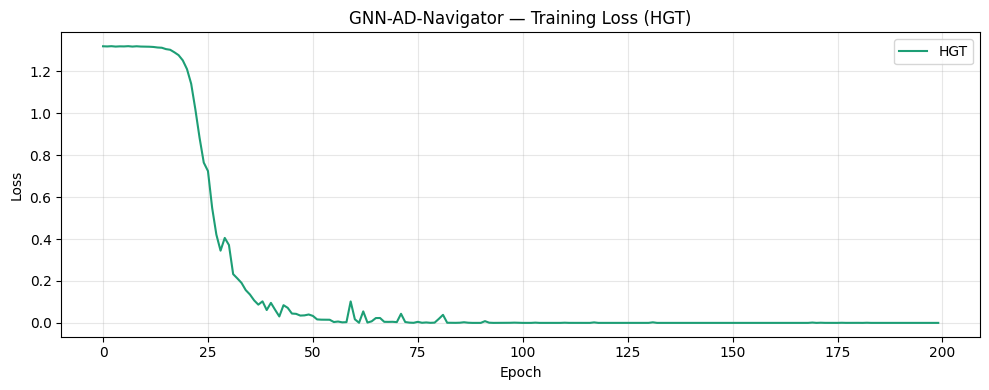

In [7]:
EPOCHS    = 500
LR        = 0.005
LOG_EVERY = 50
 
optimizer = torch.optim.Adam(model.parameters(),
                              lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=150, gamma=0.5
)
 
best_loss    = float("inf")
loss_history = []
 
print("Starting HGT training...")
print(f"  Examples  : {len(all_examples)}")
print(f"  Epochs    : {EPOCHS}")
print(f"  Heads     : {NUM_HEADS}")
print(f"  Layers    : {NUM_LAYERS}")
print("-" * 40)


PATIENCE      = 100
MIN_EPOCHS    = 200   # don't stop before this regardless of patience
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model, x_dict, edge_index_dict,
                       edge_index_flat, all_examples, optimizer)  
    loss_history.append(loss)
    
    if loss < best_loss - 1e-5:
        best_loss = loss
        patience_counter = 0
        torch.save({
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "loss":        loss,
            "architecture": "HGT",
            "hidden_dim":   HIDDEN_DIM,
            "num_heads":    NUM_HEADS,
            "num_layers":   NUM_LAYERS,
        }, CHECKPOINT_HGT)
    else:
        patience_counter += 1
    
    if epoch >= MIN_EPOCHS and patience_counter >= PATIENCE:
        print(f"Early stop at epoch {epoch}")
        break
 
    if epoch % LOG_EVERY == 0 or epoch == 1:
        print(f"Epoch {epoch:>4}  loss: {loss:.4f}  "
              f"best: {best_loss:.4f}  "
              f"lr: {scheduler.get_last_lr()[0]:.5f}")
 
print(f"\nHGT training complete. Best loss: {best_loss:.4f}")
print(f"Checkpoint → {CHECKPOINT_HGT}")
 
plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=1.5, color="#1D9E75", label="HGT")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("GNN-AD-Navigator — Training Loss (HGT)")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve_hgt.png", dpi=150)
plt.show()
 

In [8]:
# ==============================================================================
# CELL 5.5 - REWRITE HGT CHECKPOINT WITH METADATA
# ==============================================================================
# Patches the trained checkpoint to include training graph metadata.
# Required for cross-environment inference - lets the inference notebook
# rebuild HGT with the correct relation schema even when the test graph
# is missing certain edge types (e.g., missing DCSync or Shadow Credentials).
# ==============================================================================

import torch
import os

# 1. Load the freshly trained checkpoint
# (Assuming CHECKPOINT_HGT is defined earlier in your notebook)
ckpt = torch.load(CHECKPOINT_HGT, map_location="cpu", weights_only=False)

# 2. Extract metadata from the HeteroData object used during training
training_metadata = (
    ["node"],                                 # Node types (assuming single node type schema)
    [tuple(et) for et in data.edge_types],    # Full edge type tuples (src, rel, dst)
)

# 3. Add metadata + supporting architecture info to the checkpoint dictionary
ckpt["metadata"] = training_metadata
ckpt["edge_types"] = [et[1] for et in data.edge_types]  # Relation names only
ckpt["num_features"] = X.shape[1]                       # Assuming X is your feature tensor
ckpt["hidden_dim"] = HIDDEN_DIM
ckpt["num_heads"] = NUM_HEADS
ckpt["num_layers"] = NUM_LAYERS

# 4. Define a safe save path with a proper extension
# We save this to a 'results' folder to keep the Kaggle working directory clean
OUTPUT_DIR = "/kaggle/working/results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
patched_checkpoint_path = os.path.join(OUTPUT_DIR, "hgt_patched_with_metadata.pt")

# 5. Save the patched checkpoint to disk
torch.save(ckpt, patched_checkpoint_path)

# 6. Print confirmation and debug info
print(f"   Checkpoint saved to: {patched_checkpoint_path}")
print(f"   Node types : {training_metadata[0]}")
print(f"   Edge types : {len(training_metadata[1])} total relations")
print(f"   First 5    :")
for et in training_metadata[1][:5]:
    print(f"      {et}")
print(f"\n   Feature dim: {ckpt['num_features']}")

   Checkpoint saved to: /kaggle/working/results/hgt_patched_with_metadata.pt
   Node types : ['node']
   Edge types : 22 total relations
   First 5    :
      ('node', 'owns', 'node')
      ('node', 'genericwrite', 'node')
      ('node', 'writeowner', 'node')
      ('node', 'allextendedrights', 'node')
      ('node', 'writedacl', 'node')

   Feature dim: 14


In [9]:
def evaluate(model, x_dict_or_x, edge_index_dict_or_flat,
             examples, k=3, is_hgt=True):
    model.eval()
    with torch.no_grad():
        if is_hgt:
            embeddings = model.encode(x_dict_or_x, edge_index_dict_or_flat)
        else:
            embeddings = model.encode(x_dict_or_x, edge_index_dict_or_flat)
 
    hits_model = hits_random = 0
    mrr = 0.0
    total = 0
 
    for ex in examples:
        if ex["mode"] != "constrained":
            continue
        current_idx  = ex["current_idx"]
        next_hop_idx = ex["next_hop_idx"]
 
        neighbors = get_neighbors(edge_index_flat, current_idx, X.shape[0])
        if not neighbors:
            continue
        if next_hop_idx not in neighbors:
            neighbors.append(next_hop_idx)
 
        with torch.no_grad():
            scores = model.score(embeddings, current_idx, neighbors)
        ranked = [neighbors[i] for i in
                  torch.argsort(scores, descending=True).tolist()]
 
        if next_hop_idx in ranked[:k]:
            hits_model += 1
        if next_hop_idx in ranked:
            mrr += 1.0 / (ranked.index(next_hop_idx) + 1)
        if len(neighbors) <= k or next_hop_idx in random.sample(neighbors,k):
            hits_random += 1
        total += 1
 
    return {
        "precision_at_k":   hits_model  / max(total, 1),
        "random_precision": hits_random / max(total, 1),
        "mrr":              mrr         / max(total, 1),
        "total":            total,
        "k":                k,
    }
 
 
# load best HGT checkpoint
ckpt = torch.load(CHECKPOINT_HGT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded HGT checkpoint (epoch {ckpt['epoch']}, loss {ckpt['loss']:.4f})")
 
hgt_results = evaluate(model, x_dict, edge_index_dict,
                        all_examples, k=3, is_hgt=True)
 
print("\n" + "=" * 55)
print(f"{'METRIC':<30} {'HGT':>10} {'GCN':>10}")
print("=" * 55)
 
# try to load GCN results for comparison
gcn_p3 = gcn_mrr = "N/A"
try:
    from torch_geometric.nn import GCNConv
    class GCNEncoder(nn.Module):
        def __init__(self, in_c, hid):
            super().__init__()
            self.conv1 = GCNConv(in_c, hid)
            self.conv2 = GCNConv(hid, hid)
            self.bn1   = nn.BatchNorm1d(hid)
            self.bn2   = nn.BatchNorm1d(hid)
        def forward(self, x, ei):
            x = F.relu(self.bn1(self.conv1(x, ei)))
            x = F.dropout(x, 0.3, self.training)
            return F.relu(self.bn2(self.conv2(x, ei)))
 
    class GCNPolicyHead(nn.Module):
        def __init__(self, hid, pol):
            super().__init__()
            self.mlp = nn.Sequential(
                nn.Linear(hid, pol), nn.ReLU(),
                nn.Dropout(0.2), nn.Linear(pol, 1))
        def forward(self, cur, nbr):
            return self.mlp(cur.unsqueeze(0).expand_as(nbr)*nbr).squeeze(-1)
 
    class GCNNavigator(nn.Module):
        def __init__(self, in_c, hid, pol):
            super().__init__()
            self.encoder     = GCNEncoder(in_c, hid)
            self.policy_head = GCNPolicyHead(hid, pol)
        def encode(self, x, ei): return self.encoder(x, ei)
        def score(self, emb, cur, nbrs):
            return self.policy_head(emb[cur],
                   emb[torch.tensor(nbrs, device=emb.device)])

    gcn_model = GCNNavigator(X.shape[1], HIDDEN_DIM, POLICY_DIM).to(DEVICE)
    gcn_ckpt  = torch.load(CHECKPOINT_GCN, map_location=DEVICE,
                            weights_only=False)
    gcn_model.load_state_dict(gcn_ckpt["model_state"])
    gcn_model = gcn_model.to(DEVICE)  # explicit move
    gcn_model.eval()
 
    class GCNWrapper:
        def __init__(self, m): self.m = m
        def eval(self): self.m.eval()
        def encode(self, x, ei): return self.m.encode(x, ei)
        def score(self, e, c, n): return self.m.score(e, c, n)
        def __call__(self, *a): return self.m(*a)
        def parameters(self): return self.m.parameters()
 
    gcn_results = evaluate(
        gcn_model,
        X, edge_index_flat,
        all_examples, k=3, is_hgt=False
    )
    gcn_p3  = f"{gcn_results['precision_at_k']:.3f}"
    gcn_mrr = f"{gcn_results['mrr']:.3f}"
except Exception as e:
    print(f"  (GCN comparison skipped: {e})")
 
print(f"  {'Precision@3':<28} {hgt_results['precision_at_k']:>10.3f} {gcn_p3:>10}")
print(f"  {'MRR':<28} {hgt_results['mrr']:>10.3f} {gcn_mrr:>10}")
print(f"  {'Precision@3 (random)':<28} {hgt_results['random_precision']:>10.3f}")
print(f"  {'Examples evaluated':<28} {hgt_results['total']:>10}")
print("=" * 55)
 

Loaded HGT checkpoint (epoch 91, loss 0.0000)

METRIC                                HGT        GCN
  Precision@3                       1.000      1.000
  MRR                               1.000      0.985
  Precision@3 (random)              0.333
  Examples evaluated                   33


In [10]:
import math
def beam_search(model, embeddings, edge_index, start_idx,
                target_idx, beam_width=3, max_depth=8):
    beam      = [(0.0, [start_idx])]
    completed = []
 
    for _ in range(max_depth):
        candidates = []
        for log_score, path in beam:
            current = path[-1]
            if current == target_idx:
                completed.append((log_score, path))
                continue
            neighbors = get_neighbors(edge_index, current,
                                      embeddings.shape[0])
            neighbors = [n for n in neighbors if n not in path]
            if not neighbors:
                continue
            with torch.no_grad():
                scores = model.score(embeddings, current, neighbors)
                probs  = F.softmax(scores, dim=0)
            for i, nb in enumerate(neighbors):
                ns = log_score + math.log(probs[i].item() + 1e-9)
                candidates.append((ns, path + [nb]))
                if nb == target_idx:
                    completed.append((ns, path + [nb]))
 
        if not candidates:
            break
        candidates.sort(key=lambda x: x[0], reverse=True)
        beam = candidates[:beam_width]
        if len(completed) >= beam_width:
            break
 
    result = completed if completed else beam
    result.sort(key=lambda x: x[0], reverse=True)
    return result[:beam_width]
 
 
def resolve_path(path, idx_to_name):
    return " → ".join(idx_to_name.get(i, f"idx_{i}") for i in path)
 
 
# demo with objective nodes from training data
model.eval()
with torch.no_grad():
    embeddings = model.encode(x_dict, edge_index_dict)
 
obj_examples = [e for e in all_examples if e["mode"] == "constrained"]
 
print("\nBeam search demo — HGT")
print("=" * 55)
 
if len(obj_examples) >= 2:
    start_idx  = obj_examples[0]["current_idx"]
    target_idx = obj_examples[-1]["next_hop_idx"]
 
    paths = beam_search(model, embeddings, edge_index_flat,
                        start_idx, target_idx,
                        beam_width=3, max_depth=8)
 
    s_name = idx_to_name.get(start_idx,  f"idx_{start_idx}")
    t_name = idx_to_name.get(target_idx, f"idx_{target_idx}")
    print(f"Start  : {s_name}")
    print(f"Target : {t_name}")
    print(f"\nTop-{len(paths)} paths:")
 
    for rank, (score, path) in enumerate(paths, 1):
        prob = math.exp(score)
        named = resolve_path(path, idx_to_name)
        print(f"\n  Path {rank}  score: {prob:.4f}  steps: {len(path)-1}")
        print(f"  {named}")
 
print("\n" + "=" * 55)
print("Outputs saved to /kaggle/working/")
print("  best_model_hgt.pt  → HGT weights")
print("  loss_curve_hgt.png → training loss")


Beam search demo — HGT
Start  : castelblack.north.sevenkingdoms.local
Target : kingslanding.sevenkingdoms.local

Top-3 paths:

  Path 1  score: 0.0094  steps: 2
  castelblack.north.sevenkingdoms.local → enterprise key admins@sevenkingdoms.local → kingslanding.sevenkingdoms.local

  Path 2  score: 0.0000  steps: 6
  castelblack.north.sevenkingdoms.local → account operators@north.sevenkingdoms.local → jon.snow@north.sevenkingdoms.local → idx_287 → catelyn.stark@north.sevenkingdoms.local → enterprise admins@sevenkingdoms.local → kingslanding.sevenkingdoms.local

  Path 3  score: 0.0000  steps: 6
  castelblack.north.sevenkingdoms.local → account operators@north.sevenkingdoms.local → jon.snow@north.sevenkingdoms.local → idx_287 → administrator@north.sevenkingdoms.local → enterprise admins@sevenkingdoms.local → kingslanding.sevenkingdoms.local

Outputs saved to /kaggle/working/
  best_model_hgt.pt  → HGT weights
  loss_curve_hgt.png → training loss
